In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

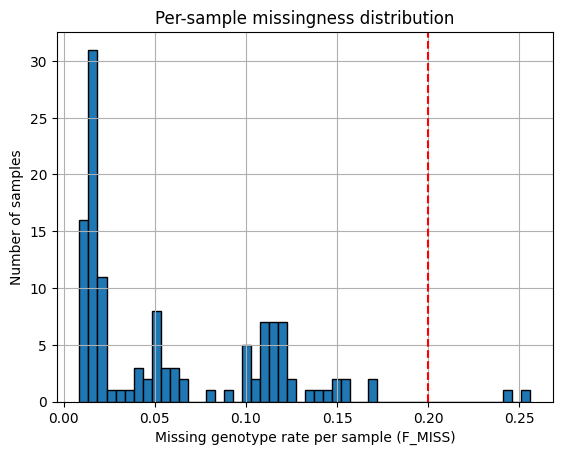

In [2]:
imiss = pd.read_csv("1_missing_maf/plink.imiss", sep=r"\s+")

plt.hist(imiss['F_MISS'], bins=50, edgecolor='black')
plt.axvline(0.2, color='red', linestyle='--')
plt.xlabel("Missing genotype rate per sample (F_MISS)")
plt.ylabel("Number of samples")
plt.title("Per-sample missingness distribution")
plt.grid(True)
plt.show()

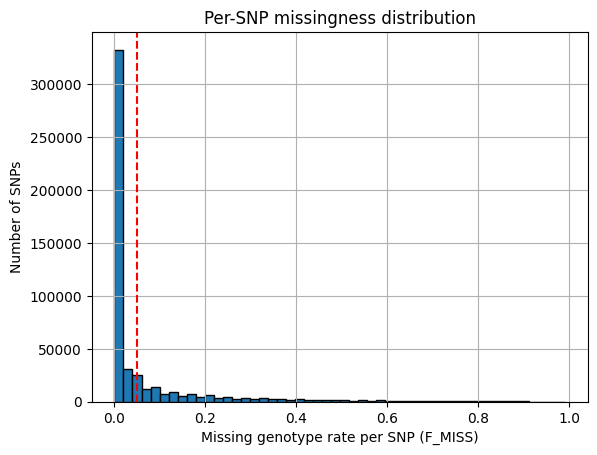

In [3]:
lmiss = pd.read_csv("1_missing_maf/plink.lmiss", sep=r"\s+")

plt.hist(lmiss['F_MISS'], bins=50, edgecolor='black')
plt.axvline(0.05, color='red', linestyle='--')
plt.xlabel("Missing genotype rate per SNP (F_MISS)")
plt.ylabel("Number of SNPs")
plt.title("Per-SNP missingness distribution")
plt.grid(True)
plt.show()

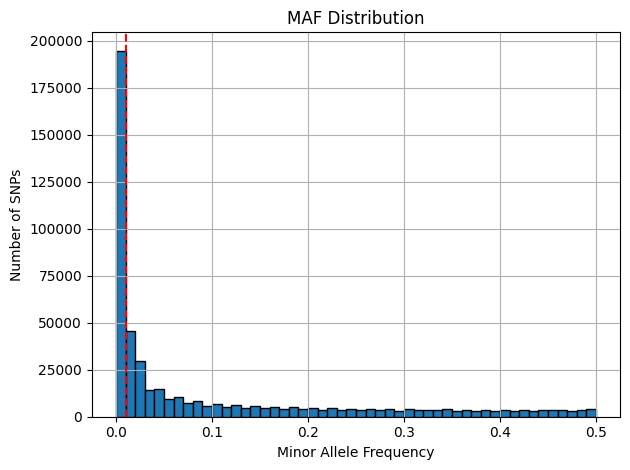

In [4]:
freqs = pd.read_csv('1_missing_maf/plink.frq', sep=r"\s+")

plt.hist(freqs['MAF'], bins=50, edgecolor='black')
plt.axvline(0.01, color='red', linestyle='--')
plt.title('MAF Distribution')
plt.xlabel('Minor Allele Frequency')
plt.ylabel('Number of SNPs')
plt.grid(True)
plt.tight_layout()
plt.show()

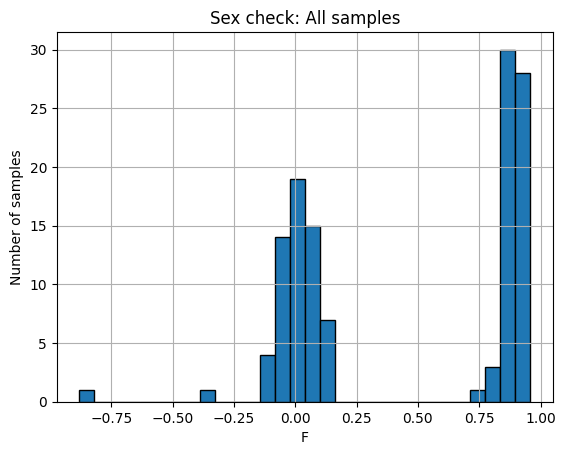

In [5]:
sc = pd.read_csv("2_sexcheck/initial_sexcheck.sexcheck", sep=r"\s+")

plt.hist(sc['F'], bins=30, edgecolor='black')
plt.xlabel("F")
plt.ylabel("Number of samples")
plt.title("Sex check: All samples")
plt.grid(True)
plt.show()

In [6]:
metadata = pd.read_csv('metadata_sex.csv', sep = ';', header = None)
metadata.columns = ['IID', 'SEX_verb']

sex_map = {"male": 1, "female": 2}
metadata["SEX"] = metadata["SEX_verb"].map(sex_map).fillna(0).astype(int)

metadata[['IID', 'SEX']].to_csv('sex_sample_info.csv', index = False)

In [7]:
exp = pd.read_csv("2_sexcheck/sex_info_sorted_exp.csv")
obs = pd.read_csv("2_sexcheck/sex_info_obs_sorted.csv", sep = '\t')

combined = pd.merge(exp, obs, on="IID", how="outer")
mismatch = combined[combined.SEX != combined.SNPSEX]
mismatch

,IID,SEX,SNPSEX
40,WE047,1,0.0
78,WE100,1,2.0
80,WE104,1,2.0
86,WE113,1,NaN
113,WE135,1,NaN


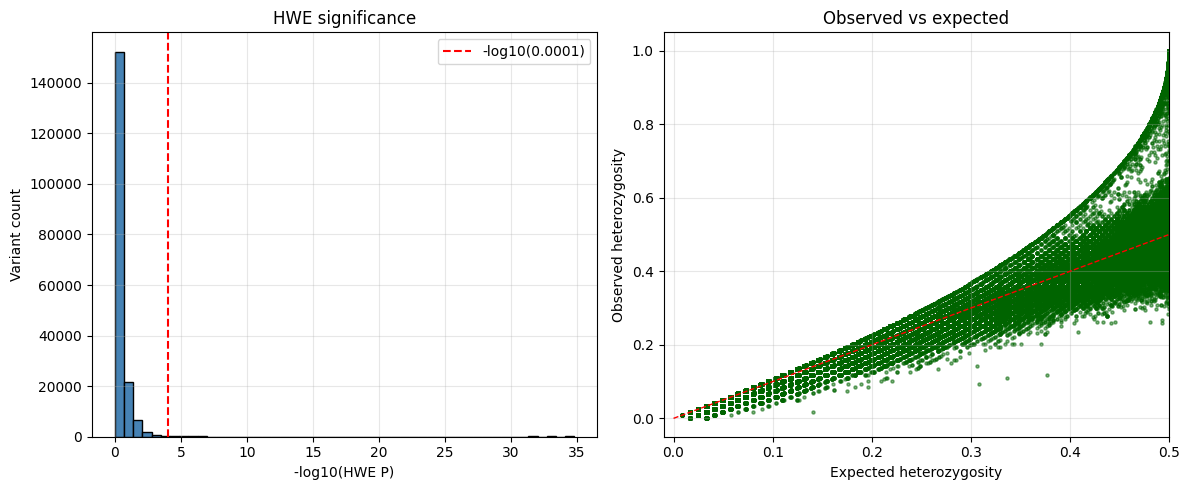

In [8]:
hwe = pd.read_csv('4_hwe/hardy.hwe', sep=r"\s+")
hwe = hwe.dropna(subset=['P'])
hwe['mlog10P'] = -np.log10(hwe['P'].clip(lower=np.finfo(float).tiny))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(hwe['mlog10P'], bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(-np.log10(1e-4), color='red', linestyle='--', label=f'-log10({1e-4:g})')
axes[0].set_xlabel('-log10(HWE P)')
axes[0].set_ylabel('Variant count')
axes[0].set_title('HWE significance')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(hwe['E(HET)'], hwe['O(HET)'], s=5, alpha=0.5, color='darkgreen')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1)
axes[1].set_xlabel('Expected heterozygosity')
axes[1].set_ylabel('Observed heterozygosity')
axes[1].set_xlim(-0.01, 0.5)
axes[1].set_title('Observed vs expected')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [9]:
het = pd.read_csv('5_het/het_stats.het', sep=r"\s+")

mean_f = het['F'].mean()
sd_f   = het['F'].std()

upper = mean_f + 3*sd_f
lower = mean_f - 3*sd_f

outliers = het[(het['F'] > upper) | (het['F'] < lower)][['FID','IID','F']]

print(f"Mean F: {mean_f:.4f}, SD F: {sd_f:.4f}")
print("Outliers:")
print(outliers)

Mean F: 0.0142, SD F: 0.1015
Outliers:
          FID        IID       F
87  WE1209921  WE1209921 -0.4858
93  WE1216321  WE1216321 -0.8092


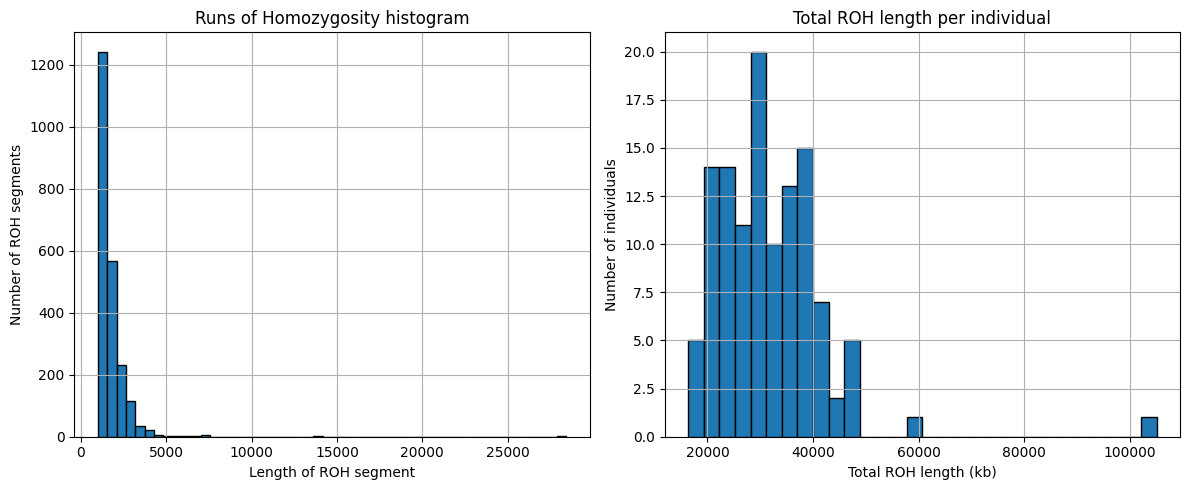

In [10]:
hom = pd.read_csv("6_roh/roh_stats.hom", sep=r"\s+")
indiv = pd.read_csv("6_roh/roh_stats.hom.indiv", sep=r"\s+")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(hom['KB'], bins=50, edgecolor='black')
axes[0].set_title('Runs of Homozygosity histogram')
axes[0].set_xlabel('Length of ROH segment')
axes[0].set_ylabel('Number of ROH segments')
axes[0].grid(True)

axes[1].hist(indiv['KB'], bins=30, edgecolor='black')
axes[1].set_title('Total ROH length per individual')
axes[1].set_xlabel('Total ROH length (kb)')
axes[1].set_ylabel('Number of individuals')
axes[1].grid(True)

plt.tight_layout()
plt.show()